In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [20]:
df = pd.read_csv("/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [21]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (768, 7)

Columns:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory

In [22]:
df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [23]:
df = df.dropna()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (740, 7)


In [24]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,5,2019
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,6,2019
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,7,2019
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,8,2019
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,9,2019


In [25]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Month,Year
count,740,740.000000,7.400000e+02,740.000000,740.000000,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122,6.390541,2019.418919
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,1.000000,2019.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,4.000000,2019.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,6.000000,2019.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,9.000000,2020.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,12.000000,2020.000000
std,NaN,10.721298,8.087988e+06,8.111094,3.235070,0.493716


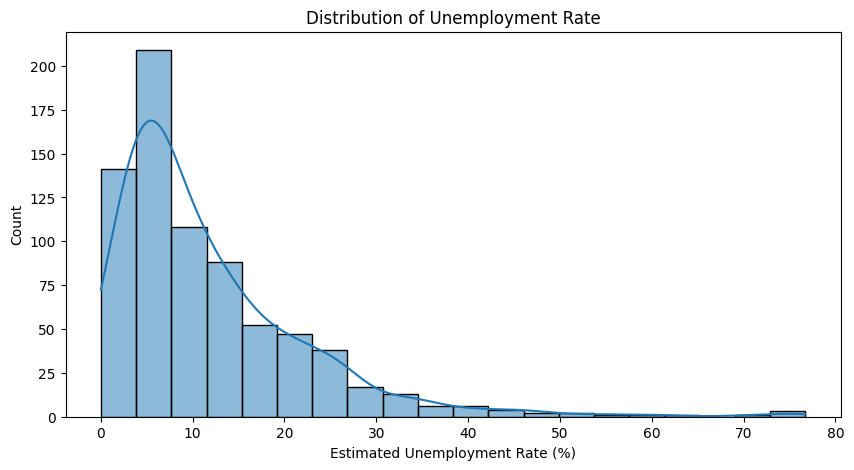

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.show()

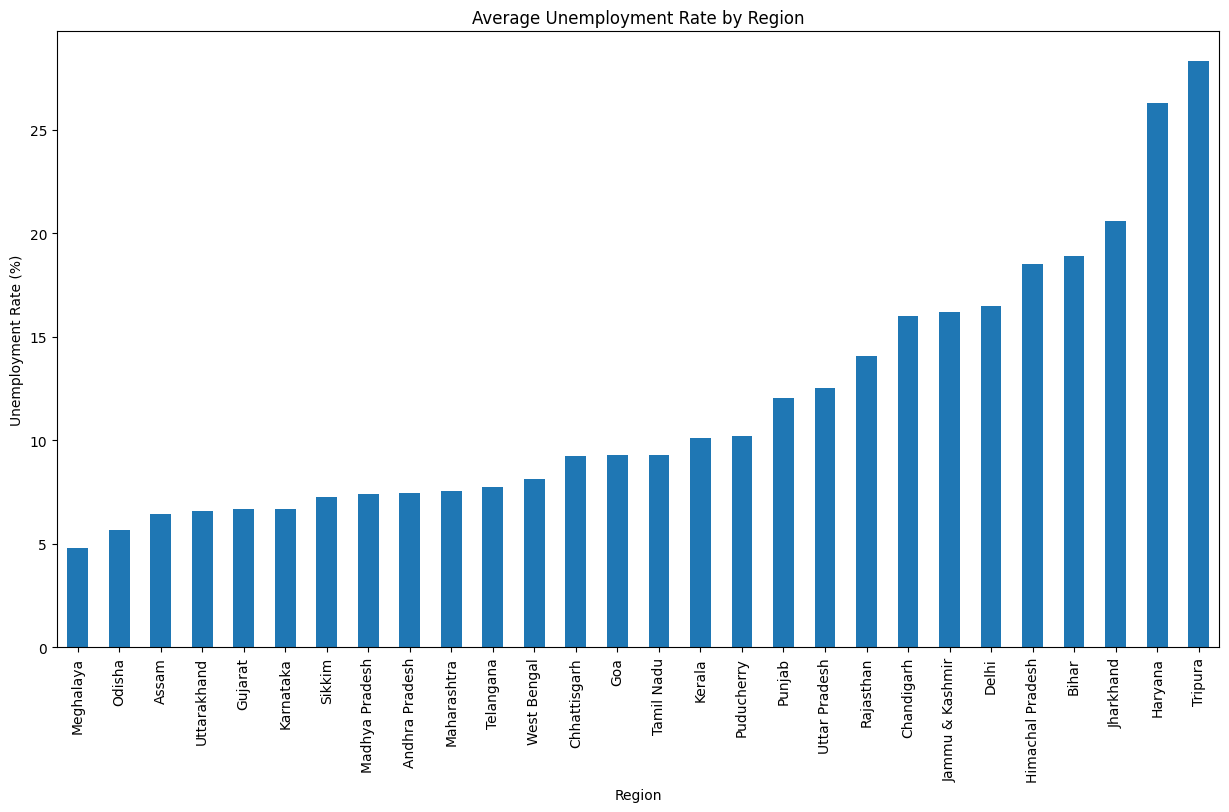

In [27]:
plt.figure(figsize=(15,8))

region_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

region_unemployment.sort_values().plot(kind='bar')

plt.title("Average Unemployment Rate by Region")
plt.ylabel("Unemployment Rate (%)")
plt.show()

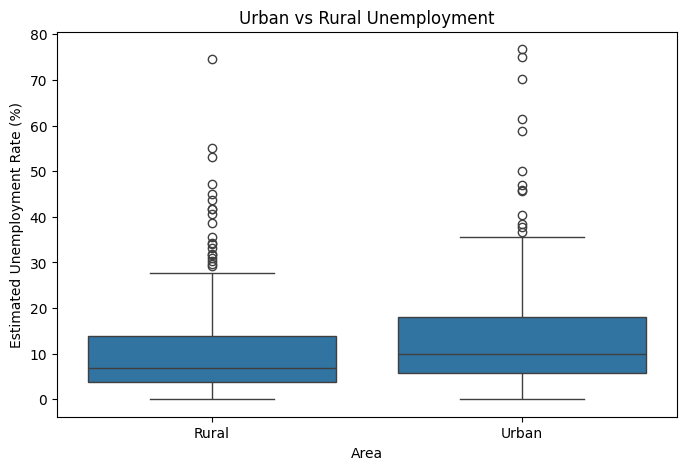

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Urban vs Rural Unemployment")
plt.show()

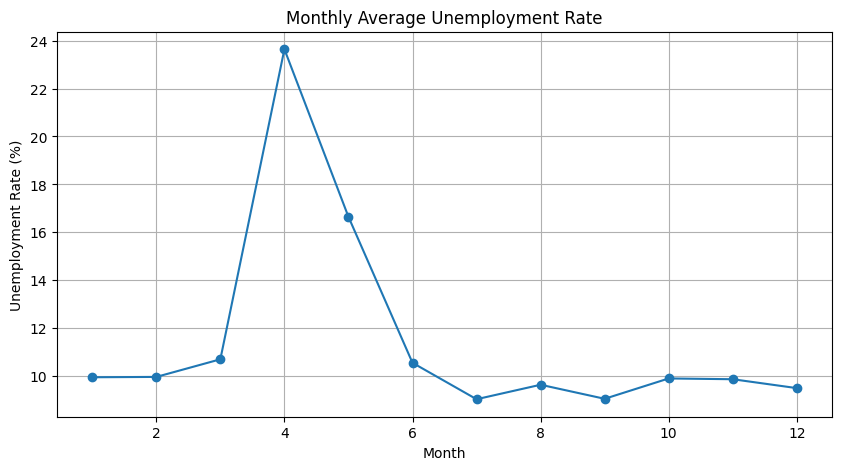

In [29]:
monthly = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker='o'
)

plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)

plt.show()

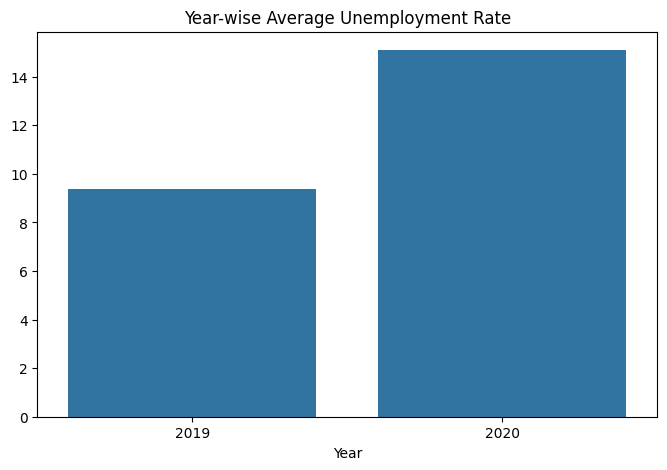

In [30]:
yearly = df.groupby('Year')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=yearly.index,
    y=yearly.values
)

plt.title("Year-wise Average Unemployment Rate")

plt.show()

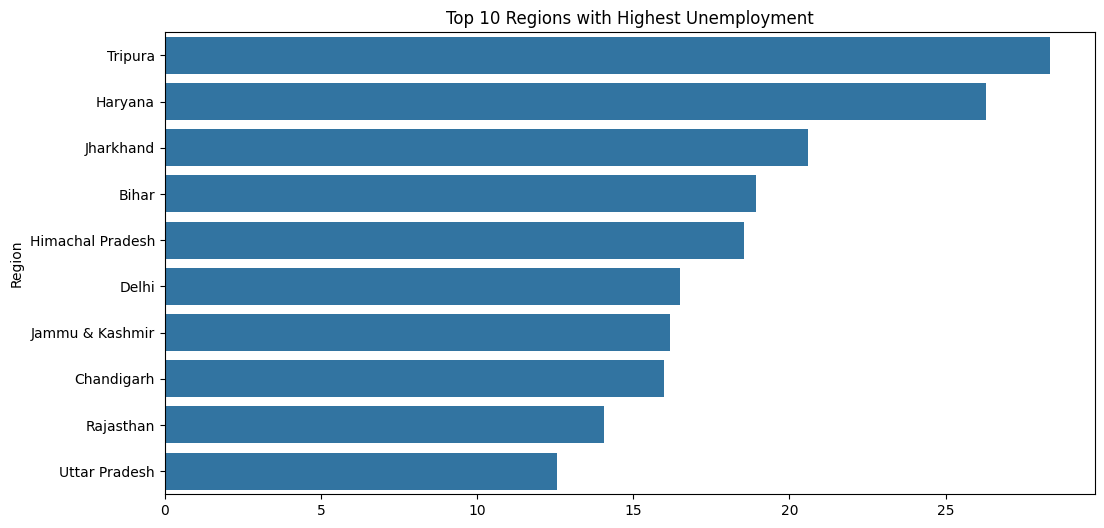

In [31]:
top10 = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

top10 = top10.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Regions with Highest Unemployment")

plt.show()

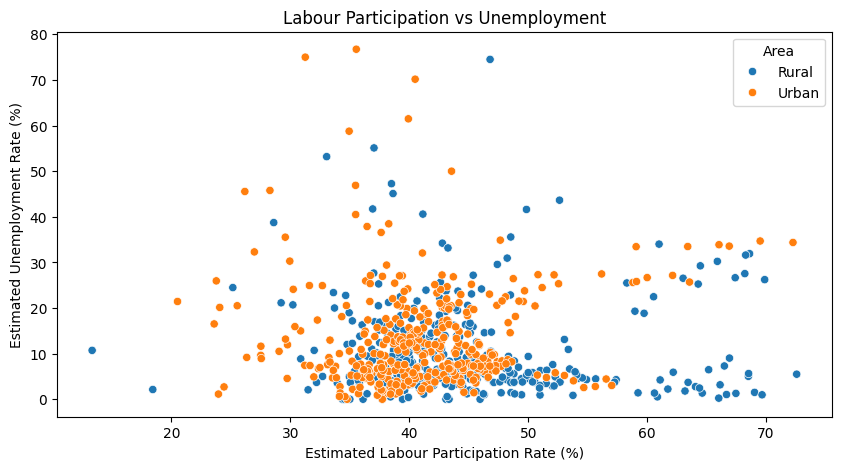

In [32]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)',
    hue='Area',
    data=df
)

plt.title("Labour Participation vs Unemployment")

plt.show()

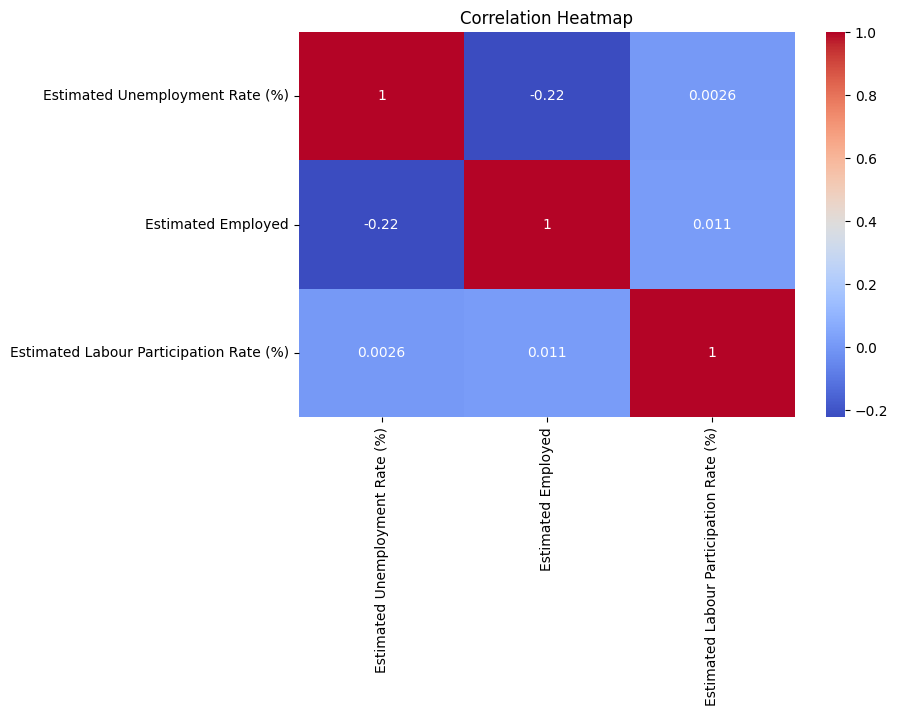

In [33]:
plt.figure(figsize=(8,5))

numeric_cols = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

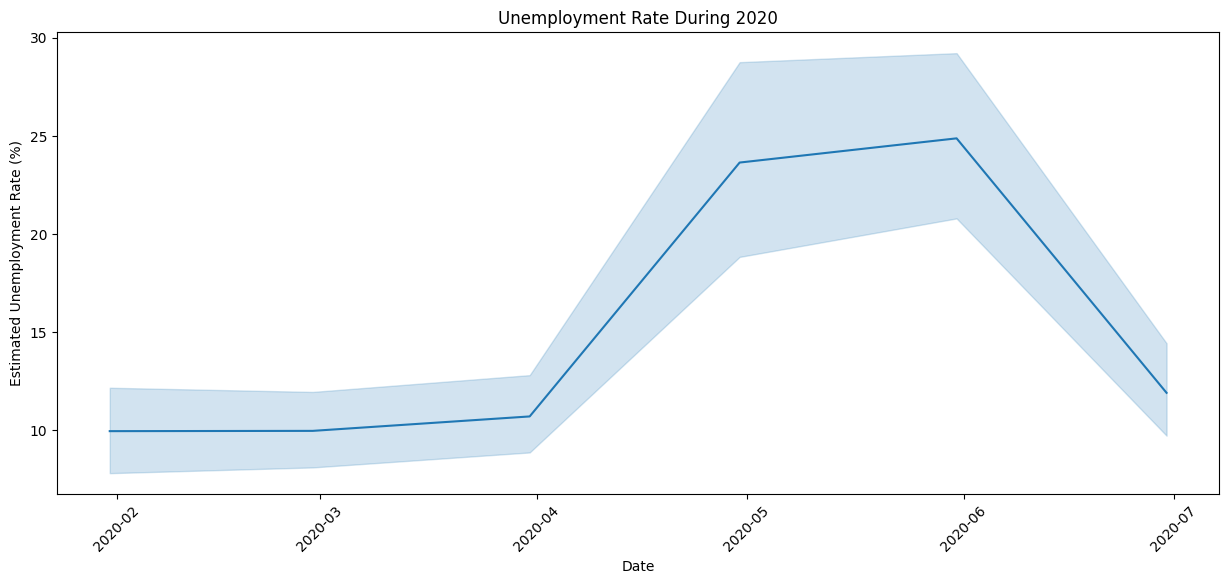

In [34]:
covid_period = df[df['Year'] == 2020]

plt.figure(figsize=(15,6))

sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=covid_period
)

plt.title("Unemployment Rate During 2020")

plt.xticks(rotation=45)

plt.show()

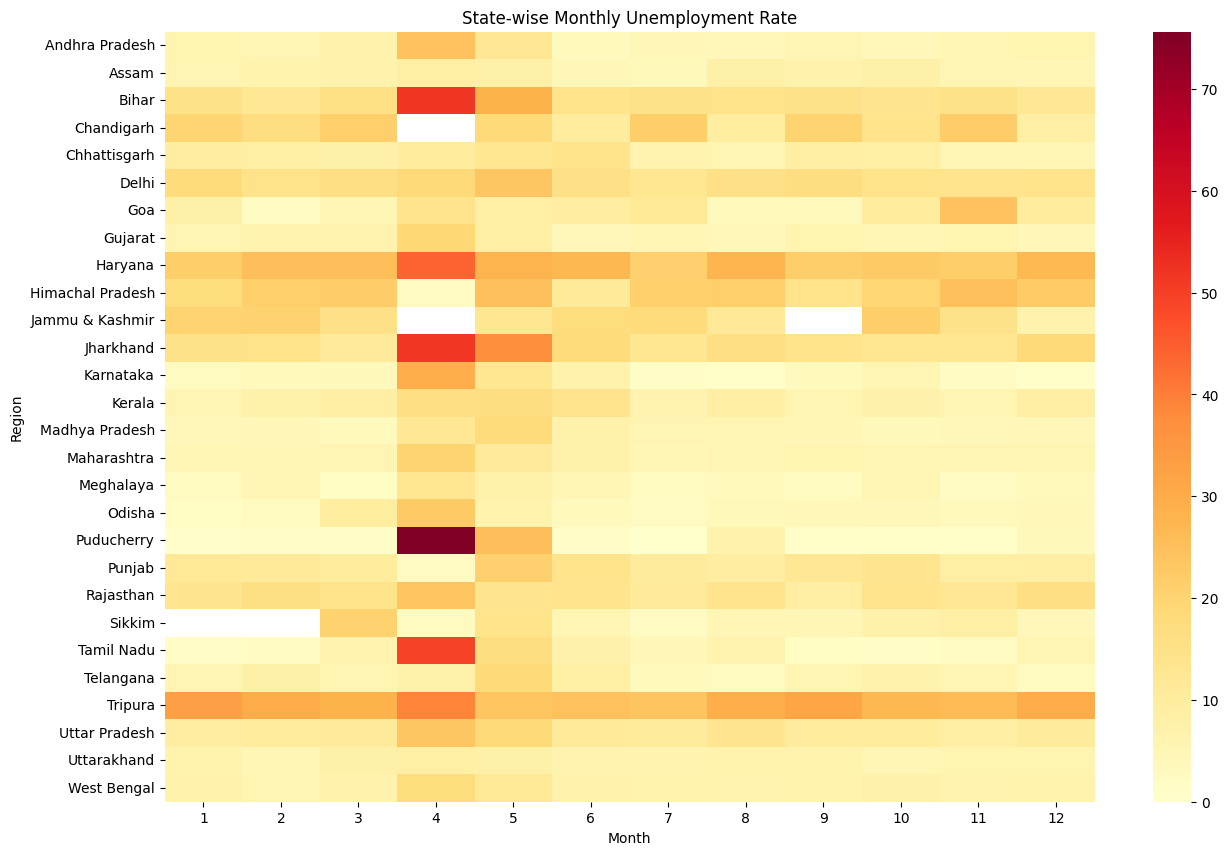

In [35]:
pivot_table = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Month'
)

plt.figure(figsize=(15,10))

sns.heatmap(
    pivot_table,
    cmap='YlOrRd'
)

plt.title("State-wise Monthly Unemployment Rate")

plt.show()

In [36]:
print("Highest Unemployment Region:")

print(
    df.groupby('Region')
      ['Estimated Unemployment Rate (%)']
      .mean()
      .sort_values(ascending=False)
      .head(1)
)

print("\nLowest Unemployment Region:")

print(
    df.groupby('Region')
      ['Estimated Unemployment Rate (%)']
      .mean()
      .sort_values()
      .head(1)
)

Highest Unemployment Region:
Region
Tripura    28.350357
Name: Estimated Unemployment Rate (%), dtype: float64

Lowest Unemployment Region:
Region
Meghalaya    4.798889
Name: Estimated Unemployment Rate (%), dtype: float64
